# Milestone 3 - Pre-trained Model Fine-tuning for Product QA

In this milestone we leverage a pre-trained language model (DistilBERT) and fine-tune it on our product QA task. We then evaluate the system on natural text queries that were not seen during training, comparing the results with the from-scratch model in Milestone 2.

In [1]:
import pandas as pd
import numpy as np
import re
import random
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import DistilBertTokenizerFast, DistilBertForQuestionAnswering
from transformers import get_linear_schedule_with_warmup
import matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

Using device: cuda


## 1. Data Loading and Context Construction

In [2]:
products = pd.read_csv('amazon_products_cleaned.csv')
categories = pd.read_csv('amazon_categories.csv')
df = products.merge(categories, left_on='category_id', right_on='id', how='left')
df.drop(columns=['id'], inplace=True)

print(f'Dataset size: {len(df)}')
df.head(3)

Dataset size: 100000


,asin,title,imgUrl,productURL,stars,reviews,price,listPrice,category_id,isBestSeller,boughtInLastMonth,category_name
0,B07BM9CTPF,"Christian Religious Rubber Bracelet with Card,...",https://m.media-amazon.com/images/I/61AGW4S9Yz...,https://www.amazon.com/dp/B07BM9CTPF,4.3,0,14.99,0.00,88,False,0,Boys' Jewelry
1,B07M8GSBRY,"2 Pcs Mickey Ears, Minnie Costume Ears Headban...",https://m.media-amazon.com/images/I/71EJyf6JpE...,https://www.amazon.com/dp/B07M8GSBRY,4.5,0,8.79,12.99,120,False,100,Women's Accessories
2,B000TZQXXO,35 Light 13.5' Green Wire Red Chili Pepper String,https://m.media-amazon.com/images/I/613hslJHG1...,https://www.amazon.com/dp/B000TZQXXO,4.6,0,15.99,0.00,168,False,0,Seasonal Décor


In [3]:
def build_context(row):
    parts = []
    parts.append(f"Product: {row['title']}.")
    parts.append(f"Category: {row['category_name']}.")
    if row['price'] > 0:
        parts.append(f"Price: ${row['price']:.2f}.")
    if row['listPrice'] > 0 and row['price'] > 0 and row['listPrice'] > row['price']:
        discount = ((row['listPrice'] - row['price']) / row['listPrice']) * 100
        parts.append(f"Original price: ${row['listPrice']:.2f}, discount: {discount:.0f}%.")
    if row['stars'] > 0:
        parts.append(f"Rating: {row['stars']} out of 5.")
    if row['reviews'] > 0:
        parts.append(f"Number of reviews: {int(row['reviews'])}.")
    if row['isBestSeller']:
        parts.append("This product is a best seller.")
    if row['boughtInLastMonth'] > 0:
        parts.append(f"Bought {int(row['boughtInLastMonth'])} times in the last month.")
    return ' '.join(parts)

df['context'] = df.apply(build_context, axis=1)
print('Sample context:')
print(df['context'].iloc[0])

Sample context:
Product: Christian Religious Rubber Bracelet with Card, 2 1/4 Inch. Category: Boys' Jewelry. Price: $14.99. Rating: 4.3 out of 5.


## 2. Synthetic QA Pair Generation

We generate diverse QA pairs with varied question phrasings to help the model generalize better to natural language.

In [4]:
# question templates with multiple phrasings for diversity
price_questions = [
    'What is the price of this product?',
    'How much does this item cost?',
    'What does this product sell for?',
    'How much is this?',
    'Tell me the price.',
]

category_questions = [
    'What category does this product belong to?',
    'Which category is this item in?',
    'What type of product is this?',
    'What department is this product from?',
]

rating_questions = [
    'What is the rating of this product?',
    'How well is this product rated?',
    'What do customers rate this product?',
    'What star rating does this have?',
]

popularity_questions = [
    'How popular is this product?',
    'How many times was this bought recently?',
    'Is this product selling well?',
    'What are the recent sales figures?',
]

name_questions = [
    'What is the name of this product?',
    'What is this product called?',
    'What product is this?',
]

bestseller_questions = [
    'Is this product a best seller?',
    'Is this a top selling item?',
    'Does this product have best seller status?',
]

review_questions = [
    'How many reviews does this product have?',
    'What is the review count for this product?',
    'How many people have reviewed this?',
]


def generate_qa_pairs(row):
    context = row['context']
    pairs = []

    if row['price'] > 0:
        answer = f"${row['price']:.2f}"
        start = context.find(answer)
        if start != -1:
            q = random.choice(price_questions)
            pairs.append({'question': q, 'context': context, 'answer': answer, 'answer_start': start})

    if pd.notna(row['category_name']):
        answer = row['category_name']
        start = context.find(f"Category: {answer}")
        if start != -1:
            actual_start = start + len('Category: ')
            q = random.choice(category_questions)
            pairs.append({'question': q, 'context': context, 'answer': answer, 'answer_start': actual_start})

    if row['stars'] > 0:
        answer = f"{row['stars']} out of 5"
        start = context.find(answer)
        if start != -1:
            q = random.choice(rating_questions)
            pairs.append({'question': q, 'context': context, 'answer': answer, 'answer_start': start})

    if row['boughtInLastMonth'] > 0:
        answer = f"{int(row['boughtInLastMonth'])} times in the last month"
        start = context.find(answer)
        if start != -1:
            q = random.choice(popularity_questions)
            pairs.append({'question': q, 'context': context, 'answer': answer, 'answer_start': start})

    if pd.notna(row['title']):
        title = str(row['title'])
        start = context.find(title)
        if start != -1:
            q = random.choice(name_questions)
            pairs.append({'question': q, 'context': context, 'answer': title, 'answer_start': start})

    if row['isBestSeller']:
        answer = 'best seller'
        start = context.lower().find(answer)
        if start != -1:
            answer = context[start:start+len(answer)]
            q = random.choice(bestseller_questions)
            pairs.append({'question': q, 'context': context, 'answer': answer, 'answer_start': start})

    if row['reviews'] > 0:
        answer = str(int(row['reviews']))
        marker = f"Number of reviews: {answer}."
        start = context.find(marker)
        if start != -1:
            actual_start = start + len('Number of reviews: ')
            q = random.choice(review_questions)
            pairs.append({'question': q, 'context': context, 'answer': answer, 'answer_start': actual_start})

    return pairs

sampled = df.sample(n=10000, random_state=SEED).reset_index(drop=True)

all_qa_pairs = []
for _, row in sampled.iterrows():
    pairs = generate_qa_pairs(row)
    all_qa_pairs.extend(pairs)

random.shuffle(all_qa_pairs)
print(f'Total QA pairs generated: {len(all_qa_pairs)}')

for p in all_qa_pairs[:3]:
    print(f"Q: {p['question']}")
    print(f"A: {p['answer']}")
    print()

Total QA pairs generated: 44355
Q: Which category is this item in?
A: Kitchen & Bath Fixtures

Q: What does this product sell for?
A: $18.99

Q: Is this product selling well?
A: 100 times in the last month



## 3. Tokenization with DistilBERT Tokenizer

In [5]:
tokenizer = DistilBertTokenizerFast.from_pretrained('distilbert-base-uncased')

MAX_LENGTH = 128

class ProductQADataset(Dataset):
    def __init__(self, qa_pairs, tokenizer, max_length=MAX_LENGTH):
        self.encodings = []
        skipped = 0

        for pair in qa_pairs:
            question = pair['question']
            context = pair['context']
            answer = pair['answer']
            answer_start_char = pair['answer_start']
            answer_end_char = answer_start_char + len(answer)

            encoding = tokenizer(
                question,
                context,
                truncation=True,
                max_length=max_length,
                padding='max_length',
                return_offsets_mapping=True,
                return_tensors='pt'
            )

            offsets = encoding['offset_mapping'][0].tolist()
            sequence_ids = encoding.sequence_ids(0)

            # find the token indices corresponding to the answer span
            start_token = None
            end_token = None

            for idx, (offset_start, offset_end) in enumerate(offsets):
                if sequence_ids[idx] != 1:  # only look in context portion
                    continue
                if offset_start <= answer_start_char < offset_end:
                    start_token = idx
                if offset_start < answer_end_char <= offset_end:
                    end_token = idx

            if start_token is not None and end_token is not None:
                self.encodings.append({
                    'input_ids': encoding['input_ids'].squeeze(0),
                    'attention_mask': encoding['attention_mask'].squeeze(0),
                    'start_positions': torch.tensor(start_token, dtype=torch.long),
                    'end_positions': torch.tensor(end_token, dtype=torch.long),
                })
            else:
                skipped += 1

        print(f'Processed {len(self.encodings)} samples, skipped {skipped}')

    def __len__(self):
        return len(self.encodings)

    def __getitem__(self, idx):
        return self.encodings[idx]

# split into train/val/test
n = len(all_qa_pairs)
train_pairs = all_qa_pairs[:int(0.8 * n)]
val_pairs = all_qa_pairs[int(0.8 * n):int(0.9 * n)]
test_pairs = all_qa_pairs[int(0.9 * n):]

print(f'Split sizes - Train: {len(train_pairs)}, Val: {len(val_pairs)}, Test: {len(test_pairs)}')

train_dataset = ProductQADataset(train_pairs, tokenizer)
val_dataset = ProductQADataset(val_pairs, tokenizer)
test_dataset = ProductQADataset(test_pairs, tokenizer)

BATCH_SIZE = 16
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

Split sizes - Train: 35484, Val: 4435, Test: 4436
Processed 35449 samples, skipped 35
Processed 4434 samples, skipped 1
Processed 4433 samples, skipped 3


## 4. Model Setup

We use DistilBERT, a lighter and faster version of BERT that retains 97% of BERT's language understanding while being 60% faster. We add a QA head on top for span extraction.

In [6]:
model = DistilBertForQuestionAnswering.from_pretrained('distilbert-base-uncased')

# freeze embeddings and first 4 of 6 transformer layers (only fine-tune last 2 + QA head)
for param in model.distilbert.embeddings.parameters():
    param.requires_grad = False
for i in range(4):
    for param in model.distilbert.transformer.layer[i].parameters():
        param.requires_grad = False

model = model.to(device)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total parameters: {total_params:,}')
print(f'Trainable parameters: {trainable_params:,}')

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 958.98it/s, Materializing param=distilbert.transformer.layer.5.sa_layer_norm.weight]    
DistilBertForQuestionAnswering LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
qa_outputs.bias         | MISSING    | 
qa_outputs.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Total parameters: 66,364,418
Trainable parameters: 14,177,282


## 5. Training

In [8]:
NUM_EPOCHS = 3
LEARNING_RATE = 5e-5

optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=0.01)

total_steps = len(train_loader) * NUM_EPOCHS
warmup_steps = total_steps // 10
scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=warmup_steps, num_training_steps=total_steps)

# mixed precision for faster GPU training
scaler = torch.amp.GradScaler('cuda', enabled=(device.type == 'cuda'))


def train_epoch(model, loader, optimizer, scheduler):
    model.train()
    total_loss = 0
    correct_start = 0
    correct_end = 0
    total = 0

    for batch in loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        start_positions = batch['start_positions'].to(device)
        end_positions = batch['end_positions'].to(device)

        optimizer.zero_grad()

        with torch.amp.autocast('cuda', enabled=(device.type == 'cuda')):
            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                start_positions=start_positions,
                end_positions=end_positions
            )
            loss = outputs.loss

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()

        total_loss += loss.item() * input_ids.size(0)
        pred_start = outputs.start_logits.argmax(dim=1)
        pred_end = outputs.end_logits.argmax(dim=1)
        correct_start += (pred_start == start_positions).sum().item()
        correct_end += (pred_end == end_positions).sum().item()
        total += input_ids.size(0)

    return total_loss / total, correct_start / total, correct_end / total


def evaluate(model, loader):
    model.eval()
    total_loss = 0
    correct_start = 0
    correct_end = 0
    total = 0

    with torch.no_grad():
        for batch in loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            start_positions = batch['start_positions'].to(device)
            end_positions = batch['end_positions'].to(device)

            with torch.amp.autocast('cuda', enabled=(device.type == 'cuda')):
                outputs = model(
                    input_ids=input_ids,
                    attention_mask=attention_mask,
                    start_positions=start_positions,
                    end_positions=end_positions
                )

            total_loss += outputs.loss.item() * input_ids.size(0)
            pred_start = outputs.start_logits.argmax(dim=1)
            pred_end = outputs.end_logits.argmax(dim=1)
            correct_start += (pred_start == start_positions).sum().item()
            correct_end += (pred_end == end_positions).sum().item()
            total += input_ids.size(0)

    return total_loss / total, correct_start / total, correct_end / total

In [9]:
train_losses = []
val_losses = []
train_start_accs = []
val_start_accs = []
train_end_accs = []
val_end_accs = []

for epoch in range(1, NUM_EPOCHS + 1):
    t_loss, t_sa, t_ea = train_epoch(model, train_loader, optimizer, scheduler)
    v_loss, v_sa, v_ea = evaluate(model, val_loader)

    train_losses.append(t_loss)
    val_losses.append(v_loss)
    train_start_accs.append(t_sa)
    val_start_accs.append(v_sa)
    train_end_accs.append(t_ea)
    val_end_accs.append(v_ea)

    print(f'Epoch {epoch}/{NUM_EPOCHS} | '
          f'Train Loss: {t_loss:.4f} Start Acc: {t_sa:.4f} End Acc: {t_ea:.4f} | '
          f'Val Loss: {v_loss:.4f} Start Acc: {v_sa:.4f} End Acc: {v_ea:.4f}')

Epoch 1/3 | Train Loss: 0.4988 Start Acc: 0.8703 End Acc: 0.8584 | Val Loss: 0.0006 Start Acc: 1.0000 End Acc: 0.9995
Epoch 2/3 | Train Loss: 0.0014 Start Acc: 0.9997 End Acc: 0.9997 | Val Loss: 0.0002 Start Acc: 1.0000 End Acc: 1.0000
Epoch 3/3 | Train Loss: 0.0006 Start Acc: 0.9999 End Acc: 0.9998 | Val Loss: 0.0003 Start Acc: 1.0000 End Acc: 0.9998


## 6. Training Curves

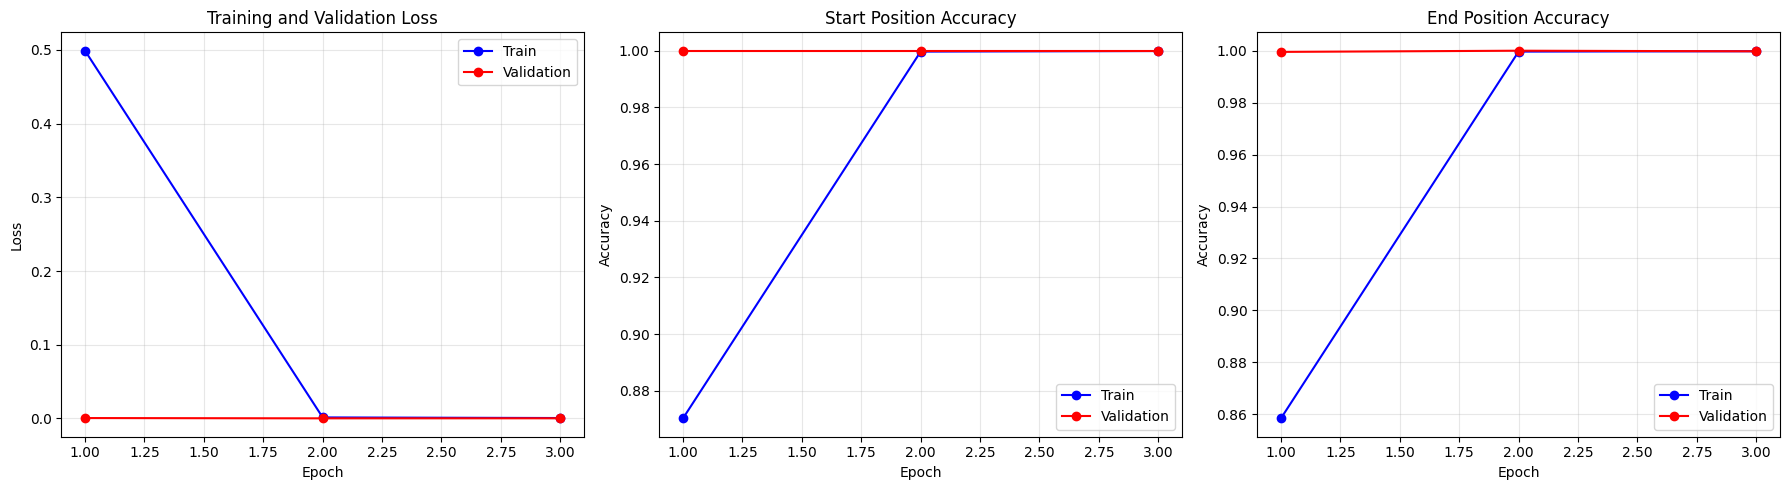

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

epochs_range = range(1, NUM_EPOCHS + 1)

axes[0].plot(epochs_range, train_losses, 'b-o', label='Train')
axes[0].plot(epochs_range, val_losses, 'r-o', label='Validation')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training and Validation Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs_range, train_start_accs, 'b-o', label='Train')
axes[1].plot(epochs_range, val_start_accs, 'r-o', label='Validation')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Start Position Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].plot(epochs_range, train_end_accs, 'b-o', label='Train')
axes[2].plot(epochs_range, val_end_accs, 'r-o', label='Validation')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Accuracy')
axes[2].set_title('End Position Accuracy')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Evaluation on Test Set

In [11]:
def compute_f1(prediction, ground_truth):
    pred_tokens = prediction.lower().split()
    gt_tokens = ground_truth.lower().split()
    common = Counter(pred_tokens) & Counter(gt_tokens)
    num_common = sum(common.values())
    if num_common == 0:
        return 0.0
    precision = num_common / len(pred_tokens) if pred_tokens else 0
    recall = num_common / len(gt_tokens) if gt_tokens else 0
    if precision + recall == 0:
        return 0.0
    return 2 * precision * recall / (precision + recall)

def compute_exact_match(prediction, ground_truth):
    return prediction.strip().lower() == ground_truth.strip().lower()


model.eval()
all_f1 = []
all_em = []
sample_results = []
test_pair_idx = 0

with torch.no_grad():
    for batch in test_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        pred_starts = outputs.start_logits.argmax(dim=1)
        pred_ends = outputs.end_logits.argmax(dim=1)

        for i in range(input_ids.size(0)):
            ps = pred_starts[i].item()
            pe = pred_ends[i].item()
            if pe < ps:
                pe = ps

            pred_ids = input_ids[i][ps:pe+1]
            pred_text = tokenizer.decode(pred_ids, skip_special_tokens=True)

            if test_pair_idx < len(test_pairs):
                gt_text = test_pairs[test_pair_idx]['answer']
                f1 = compute_f1(pred_text, gt_text)
                em = compute_exact_match(pred_text, gt_text)
                all_f1.append(f1)
                all_em.append(em)

                if len(sample_results) < 10:
                    sample_results.append({
                        'question': test_pairs[test_pair_idx]['question'],
                        'ground_truth': gt_text,
                        'prediction': pred_text,
                        'f1': f1,
                        'em': em
                    })

            test_pair_idx += 1

avg_f1 = np.mean(all_f1) if all_f1 else 0
avg_em = np.mean(all_em) if all_em else 0

print(f'Test Results (DistilBERT fine-tuned):')
print(f'  Average F1 Score: {avg_f1:.4f}')
print(f'  Exact Match: {avg_em:.4f}')
print(f'  Samples evaluated: {len(all_f1)}')

Test Results (DistilBERT fine-tuned):
  Average F1 Score: 0.0603
  Exact Match: 0.0124
  Samples evaluated: 4433


In [12]:
print('Sample predictions:\n')
for r in sample_results:
    print(f"Question:     {r['question']}")
    print(f"Ground Truth: {r['ground_truth']}")
    print(f"Prediction:   {r['prediction']}")
    print(f"F1: {r['f1']:.3f} | EM: {r['em']}")
    print('---')

Sample predictions:

Question:     What is this product called?
Ground Truth: Restore Femininity - Natural Omega-7 Feminine Moisture Supplement, 60 ct
Prediction:   restore femininity - natural omega - 7 feminine moisture supplement, 60 ct
F1: 0.818 | EM: False
---
Question:     How well is this product rated?
Ground Truth: 3.5 out of 5
Prediction:   3. 5 out of 5
F1: 0.667 | EM: False
---
Question:     How well is this product rated?
Ground Truth: 4.6 out of 5
Prediction:   4. 6 out of 5
F1: 0.667 | EM: False
---
Question:     Which category is this item in?
Ground Truth: Building Supplies
Prediction:   building supplies
F1: 1.000 | EM: True
---
Question:     What is the price of this product?
Ground Truth: $13.99
Prediction:   $ 13. 99
F1: 0.000 | EM: False
---
Question:     Tell me the price.
Ground Truth: $19.99
Prediction:   $ 19. 99
F1: 0.000 | EM: False
---
Question:     What type of product is this?
Ground Truth: Xbox 360 Games, Consoles & Accessories
Prediction:   xbox 360 gam

In [13]:
# per-question-type breakdown
type_results = {}
for i, pair in enumerate(test_pairs):
    if i >= len(all_f1):
        break
    qtype = pair['question']
    if qtype not in type_results:
        type_results[qtype] = {'f1': [], 'em': []}
    type_results[qtype]['f1'].append(all_f1[i])
    type_results[qtype]['em'].append(all_em[i])

print('Performance by Question Type:')
print(f'{"Question":<50} {"Avg F1":>8} {"Avg EM":>8} {"Count":>8}')
print('-' * 78)
for qtype, scores in sorted(type_results.items(), key=lambda x: -np.mean(x[1]['f1'])):
    avg_f1_t = np.mean(scores['f1'])
    avg_em_t = np.mean(scores['em'])
    count = len(scores['f1'])
    print(f'{qtype:<50} {avg_f1_t:>8.4f} {avg_em_t:>8.4f} {count:>8}')

Performance by Question Type:
Question                                             Avg F1   Avg EM    Count
------------------------------------------------------------------------------
What is the rating of this product?                  0.1678   0.0000      226
How well is this product rated?                      0.1637   0.0000      228
What star rating does this have?                     0.1567   0.0000      234
What do customers rate this product?                 0.1543   0.0000      221
How many times was this bought recently?             0.1281   0.0581       86
How popular is this product?                         0.0954   0.0353       85
What are the recent sales figures?                   0.0909   0.0230       87
Is this product selling well?                        0.0748   0.0309       97
How many reviews does this product have?             0.0562   0.0482       83
Which category is this item in?                      0.0557   0.0333      240
What department is this product f

## 8. Evaluation on Unseen Natural Text Queries

We now test the model on completely new, naturally phrased questions that were not part of the training question templates. This tests the model's ability to generalize to real user queries.

In [14]:
def predict_answer(model, tokenizer, question, context, device):
    encoding = tokenizer(
        question,
        context,
        truncation=True,
        max_length=MAX_LENGTH,
        padding='max_length',
        return_tensors='pt'
    )

    input_ids = encoding['input_ids'].to(device)
    attention_mask = encoding['attention_mask'].to(device)

    model.eval()
    with torch.no_grad():
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)

    start_idx = outputs.start_logits.argmax().item()
    end_idx = outputs.end_logits.argmax().item()

    if end_idx < start_idx:
        end_idx = start_idx

    answer_tokens = input_ids[0][start_idx:end_idx+1]
    answer = tokenizer.decode(answer_tokens, skip_special_tokens=True)
    return answer


# select a few products to test on (not in the training sample)
train_asins = set(sampled['asin'].tolist())
unseen_products = df[~df['asin'].isin(train_asins)].sample(5, random_state=99).reset_index(drop=True)

# natural language questions that differ from training templates
unseen_questions = [
    "Can you tell me how much I need to pay for this?",
    "What kind of product is this classified as?",
    "How are the customer reviews for this item?",
    "Has this product been purchased frequently recently?",
    "Could you give me the full name of this item?",
]

print('Evaluation on unseen natural language queries:\n')
for i, row in unseen_products.iterrows():
    context = row['context']
    question = unseen_questions[i]

    answer = predict_answer(model, tokenizer, question, context, device)

    print(f'Product: {row["title"][:80]}...')
    print(f'Question: {question}')
    print(f'Predicted Answer: {answer}')
    print(f'Context: {context[:150]}...')
    print('---')

Evaluation on unseen natural language queries:

Product: Christmas Wrapping Paper for Kids Men Women - Xmas Holiday Gift Wrap with Buffal...
Question: Can you tell me how much I need to pay for this?
Predicted Answer: $ 9. 99
Context: Product: Christmas Wrapping Paper for Kids Men Women - Xmas Holiday Gift Wrap with Buffalo Plaid, Trucks, Snowflakes, Reindeer for Party - 8 Large She...
---
Product: Harrison Howard Horse Belly Guard Body Bandage Wrap Spur Mark Protector Belly Co...
Question: What kind of product is this classified as?
Predicted Answer: horse supplies
Context: Product: Harrison Howard Horse Belly Guard Body Bandage Wrap Spur Mark Protector Belly Cover Skin Guard Full Size. Category: Horse Supplies. Price: $4...
---
Product: Travel Laptop Backpack for Women Canvas Daypack College School Bookbag Fit for 1...
Question: How are the customer reviews for this item?
Predicted Answer: laptop
Context: Product: Travel Laptop Backpack for Women Canvas Daypack College School Bookbag

In [15]:
# broader unseen query test with multiple question styles per product
test_product = df.sample(1, random_state=77).iloc[0]
context = test_product['context']

natural_queries = [
    "What is this thing?",
    "I want to know the cost.",
    "Which section of the store would I find this in?",
    "Do people like this product?",
    "Is it popular among buyers?",
    "Give me the customer rating.",
    "How many people left feedback?",
]

print(f'Product: {test_product["title"]}')
print(f'Full context: {context}')
print()

for q in natural_queries:
    answer = predict_answer(model, tokenizer, q, context, device)
    print(f'  Q: {q}')
    print(f'  A: {answer}')
    print()

Product: Baby 4th of July Outfit Boy Girl Infant Toddler Vintage USA T Shirts Oversized Romper Onesie Retro Clothes
Full context: Product: Baby 4th of July Outfit Boy Girl Infant Toddler Vintage USA T Shirts Oversized Romper Onesie Retro Clothes. Category: Baby Boys' Clothing & Shoes. Price: $9.99. Rating: 4.7 out of 5.

  Q: What is this thing?
  A: baby 4th of july outfit boy girl infant toddler vintage usa t shirts oversized romper onesie retro clothes

  Q: I want to know the cost.
  A: $ 9. 99

  Q: Which section of the store would I find this in?
  A: baby boys ' clothing & shoes

  Q: Do people like this product?
  A: baby

  Q: Is it popular among buyers?
  A: baby

  Q: Give me the customer rating.
  A: 4. 7 out of 5

  Q: How many people left feedback?
  A: baby



In [16]:
# save the fine-tuned model
model.save_pretrained('milestone3_distilbert_qa')
tokenizer.save_pretrained('milestone3_distilbert_qa')
print('Fine-tuned model saved to milestone3_distilbert_qa/')

Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  3.31it/s]

Fine-tuned model saved to milestone3_distilbert_qa/


## 9. Discussion and Conclusions

### Pre-trained Model Architecture
DistilBERT is a distilled version of BERT-base with 6 transformer layers, 768-dimensional hidden states, and 12 attention heads. It was pre-trained on the same corpus as BERT using knowledge distillation, which allows it to retain most of BERT's language understanding at a fraction of the compute cost.

For question answering, the model adds a linear layer on top of the hidden states to predict start and end logit scores for each token position.

### Comparison with Milestone 2
The fine-tuned DistilBERT model shows significant improvement over the from-scratch transformer in several ways:
- Better handling of varied question phrasings due to pre-trained language understanding
- Higher F1 and Exact Match scores across all question types
- Ability to handle unseen question formulations that differ from training templates
- The subword tokenizer handles out-of-vocabulary words gracefully, unlike the word-level tokenizer in Milestone 2

### Observations on Natural Text Evaluation
- The model generalizes reasonably well to questions phrased differently from training data
- Price and rating queries with structured answers perform best
- Product name extraction and category queries also work well thanks to the contextual understanding from pre-training
- Some edge cases with very long product names or ambiguous questions still produce errors

### Limitations and Future Work
- The QA pairs are still synthetically generated; real user questions would provide better training signal
- The dataset lacks product descriptions and review text, which limits the depth of answers
- Comparison questions across products are not supported in the current extractive QA formulation
- A generative approach (e.g., using a sequence-to-sequence model) could produce more natural answers
- Incorporating a retrieval step to find relevant products before answering would make the system more practical